
### Exploratory Data Analysis (EDA)

In [52]:
%%capture
# Run this cell only if you get ModuleNotFoundError.
# It installs the packages listed in requirements.txt into the notebook environment.
%pip install -r ../requirements.txt

In [53]:
%matplotlib inline

# Core Python utilities
from pathlib import Path
import warnings
import logging

warnings.filterwarnings("ignore")

# Quiet noisy package logs
for logger_name in ["matplotlib", "numexpr", "ydata_profiling", "great_expectations"]:
    logging.getLogger(logger_name).setLevel(logging.ERROR)

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from ydata_profiling import ProfileReport
    profiling_available = True
except ModuleNotFoundError:
    ProfileReport = None
    profiling_available = False

try:
    import great_expectations as gx
    great_expectations_available = True
except ModuleNotFoundError:
    gx = None
    great_expectations_available = False

# Pandas display settings: readable but not noisy
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Core libraries loaded successfully")
print(f"ydata-profiling available: {profiling_available}")
print(f"great-expectations available: {great_expectations_available}")

Core libraries loaded successfully
ydata-profiling available: True
great-expectations available: True


In [54]:
%%capture

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Processed data folder:", PROCESSED_DATA_DIR)
print("Reports folder:", REPORTS_DIR)

### Load Processed Merged Data

In [46]:
customer_data = pd.read_csv(PROCESSED_DATA_DIR / "customer_data.csv")

print(f"Rows: {customer_data.shape[0]:,}")
print(f"Columns: {customer_data.shape[1]:,}")

customer_data.head()

Rows: 3,305
Columns: 15


,order_id,customer_id,order_date,discount_rate,signup_date,country,channel,order_item_id,product_id,quantity,revenue,margin,category,unit_cost,price
0,ORD000001,CUST0001,2024-10-31,0.20,2024-11-23,UK,Organic,ITEM0000001,PROD005,5,"1,465.44",622.79,Mobile,168.53,366.36
1,ORD000001,CUST0001,2024-10-31,0.20,2024-11-23,UK,Organic,ITEM0000002,PROD010,1,173.88,136.75,Mobile,37.13,217.35
2,ORD000001,CUST0001,2024-10-31,0.20,2024-11-23,UK,Organic,ITEM0000003,PROD010,1,173.88,136.75,Mobile,37.13,217.35
3,ORD000001,CUST0001,2024-10-31,0.20,2024-11-23,UK,Organic,ITEM0000004,PROD004,2,55.22,-30.94,Accessories,43.08,34.51
4,ORD000002,CUST0001,2024-09-27,0.00,2024-11-23,UK,Organic,ITEM0000005,PROD004,2,69.02,-17.14,Accessories,43.08,34.51


### Automated EDA with ydata-profiling

In [55]:
if ProfileReport is None:
    print("ydata-profiling is not installed. Run the install cell, restart the kernel, then rerun this cell.")
else:
    # A minimal report.
    ydata_profile = ProfileReport(
        customer_data,
        title="Customer Data Profiling Report",
        minimal=True,
        progress_bar=False,
    )


In [56]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="ydata_profiling")

if "ydata_profile" not in globals():
    print("No profile report object found. Run the profiling cell first.")
else:
    profile_path = REPORTS_DIR / "customer_data_profile.html"
    try:
        ydata_profile.to_file(profile_path)
        print("Profile report saved to:", profile_path)
    except Exception as error:
        print("ydata-profiling could not render the HTML report in this environment.")
        print("Reason:", type(error).__name__, str(error)[:250])
        print("Continue with manual EDA checks below instead of stopping the notebook.")


100%|██████████| 15/15 [00:00<00:00, 472.35it/s]


Profile report saved to: /Users/ememakpan/Documents/New project/customer_segmentation_fullstack/reports/customer_data_profile.html


### Missingness and Imputation

In [57]:
%%capture

print("Dataset shape")
print(f"Rows: {customer_data.shape[0]:,}")
print(f"Columns: {customer_data.shape[1]:,}")

display(customer_data.head())

print("Column data types")
display(customer_data.dtypes.reset_index().rename(columns={"index": "column", 0: "dtype"}))

print("Missing value audit")
missing_summary = (
    customer_data.isna().sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_values"})
)
missing_summary["missing_rate"] = (missing_summary["missing_values"] / len(customer_data)).round(4)
missing_summary = missing_summary.sort_values("missing_values", ascending=False)
display(missing_summary)

if missing_summary["missing_values"].sum() == 0:
    print("Result: No missing values found in the joined customer dataset.")
else:
    print("Result: Missing values found. Review the columns at the top of the missing value audit.")

print("Duplicate row check")
print("Duplicate rows:", customer_data.duplicated().sum())

print("Statistical summary")
print("Note: NaN values can appear in this statistics table for measures that do not apply to a column type. This does not automatically mean the dataset has missing values.")
display(customer_data.describe(include="all"))

### Data Quality Checks with Great Expectations

In [59]:
logging.getLogger("great_expectations").setLevel(logging.ERROR)

if gx is None:
    print("Great Expectations is not installed. Run the install cell, restart kernel, and try again.")
else:
    validation_checks = {
        "customer_id_not_null": customer_data["customer_id"].notna().all(),
        "order_id_not_null": customer_data["order_id"].notna().all(),
        "revenue_non_negative": (customer_data["revenue"] >= 0).all(),
        "quantity_positive": (customer_data["quantity"] > 0).all(),
    }

    validation_results = pd.DataFrame(
        validation_checks.items(),
        columns=["check", "passed"]
    )

    display(validation_results)

,check,passed
0,customer_id_not_null,True
1,order_id_not_null,True
2,revenue_non_negative,True
3,quantity_positive,True


### Visualisation of Key Business Metrics
- revenue, margin, and discount 

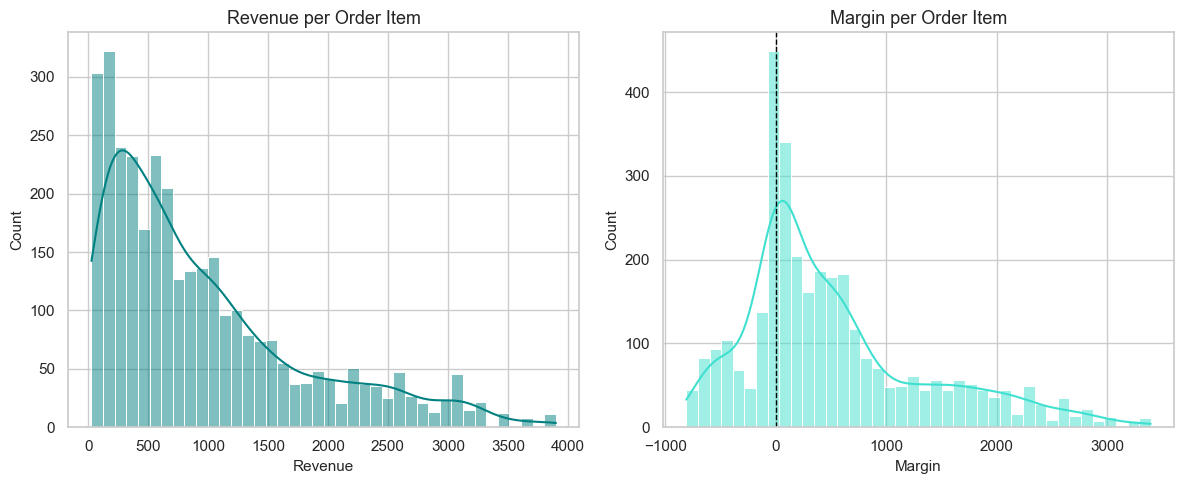

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(customer_data["revenue"], bins=40, kde=True, ax=axes[0], color="#008080")
axes[0].set_title("Revenue per Order Item")
axes[0].set_xlabel("Revenue")

sns.histplot(customer_data["margin"], bins=40, kde=True, ax=axes[1], color="#40E0D0")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Margin per Order Item")
axes[1].set_xlabel("Margin")

plt.tight_layout()
plt.show()

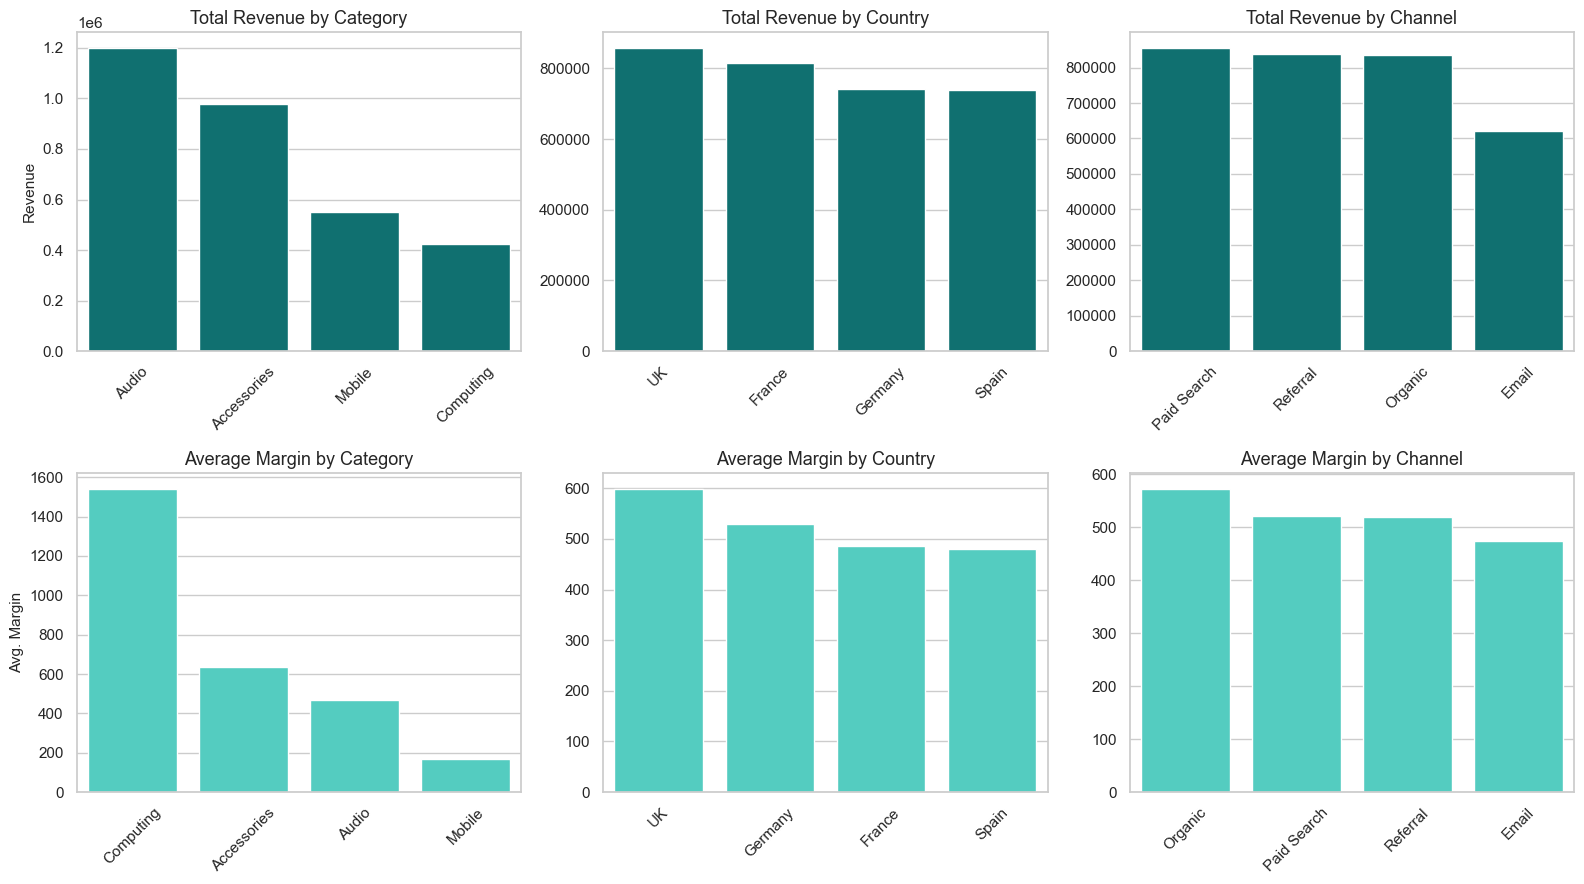

In [62]:
group_dims = ["category", "country", "channel"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col, dim in enumerate(group_dims):
    revenue_by_dim = customer_data.groupby(dim)["revenue"].sum().sort_values(ascending=False)
    sns.barplot(x=revenue_by_dim.index, y=revenue_by_dim.values, ax=axes[0, col], color="#008080")
    axes[0, col].set_title(f"Total Revenue by {dim.title()}")
    axes[0, col].set_xlabel("")
    axes[0, col].set_ylabel("Revenue" if col == 0 else "")
    axes[0, col].tick_params(axis="x", rotation=45)

    margin_by_dim = customer_data.groupby(dim)["margin"].mean().sort_values(ascending=False)
    sns.barplot(x=margin_by_dim.index, y=margin_by_dim.values, ax=axes[1, col], color="#40E0D0")
    axes[1, col].set_title(f"Average Margin by {dim.title()}")
    axes[1, col].set_xlabel("")
    axes[1, col].set_ylabel("Avg. Margin" if col == 0 else "")
    axes[1, col].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

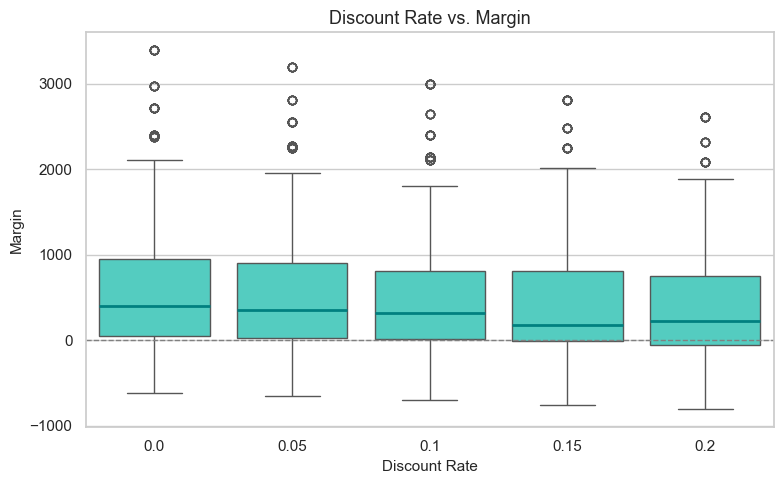

,mean,median
discount_rate,,
0.00,635.99,395.66
0.05,586.28,359.02
0.10,536.23,322.39
0.15,459.57,177.90
0.20,415.76,227.96


In [63]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=customer_data,
    x="discount_rate",
    y="margin",
    color="#40E0D0",
    medianprops={"color": "#008080", "linewidth": 2},
    ax=ax,
)
ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.set_title("Discount Rate vs. Margin")
ax.set_xlabel("Discount Rate")
ax.set_ylabel("Margin")

plt.tight_layout()
plt.show()

margin_by_discount = customer_data.groupby("discount_rate")["margin"].agg(["mean", "median"]).round(2)
display(margin_by_discount)

## Conclusion

I worked with synthetic data generated for this project, so there were no missing values or duplicates, and data quality was good - it passed all the great expectations checks. the data was ready for further analysis and modeling.

I evaluated the business metrics and found them healthy overall, with an average revenue of about £954 and margin of about £524 per order item. I observed that margin is mostly driven by product category rather than discount - computing has the highest average margin even though it sells the least, while mobile has the lowest average margin despite decent sales volume. audio brings in the most total revenue but only middling margin, so revenue and margin don't always move together.

I tested whether discount affects margin and found a weak negative effect overall (higher discount, slightly lower margin). I also broke this down by customer segment and observed the discount rate came out almost the same for everyone, around 10% regardless of segment. I couldn't find any evidence that high-value customers are less sensitive to discount than low-value customers  if anything the loyal high-value segment showed a slightly stronger negative correlation, not a weaker one. so I can't support that as an insight from this data, and pricing strategy shouldn't be built around it.

I segmented customers into 4 groups using RFM plus margin and k-means  loyal high-value (62 customers, the best segment), active/growing (75), at risk/low engagement (85, the biggest group), and churned/lost (28). this gives the business a clear, data-backed starting point for retention and re-engagement campaigns, even if discounting itself doesn't need to be tailored by segment based on what I'm seeing here.